# DLQG en variables differentielles

Ce notebook compare le DLQG original au DLQG delta-state sur les deux mouvements de grande amplitude du projet.
La commande delta utilise $u_k=-L_k\hat{\delta x}_k$, avec $\delta x=x-x_\star$ et la meme dynamique, le meme delai, les memes poids et le meme bruit moteur.

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

import os
os.chdir('..')
from Controllers.LQGControllers import DLQG_6Muscles
from Helpers.Helpers import compute_angles_from_cartesian, longmovement_1, longmovement_2

DURATION = 0.6
NUM_ITER = 60
NUM_SIM = 50
CONTROLLERS = ('DLQG', 'delta-DLQG')

def cost_function(x, u, target):
    target_angles = compute_angles_from_cartesian(target[0], target[1])
    shoulder, elbow, shoulder_velocity, elbow_velocity = x[-1, :4]
    return 20000 * ((shoulder - target_angles[0]) ** 2 + (elbow - target_angles[1]) ** 2) + (shoulder_velocity ** 2 + elbow_velocity ** 2) + 0.02 * np.sum(u * u)


## Simulation et indicateurs

In [2]:
def run_one(movement, noise=True):
    start, target = movement()
    kwargs = dict(Duration=DURATION, Num_iter=NUM_ITER, starting_point=start, targets=target, plot=False, Delay=0.06, Activate_Noise=noise, motornoise_variance=5e-4, w1=20000, w2=20000, w3=1, w4=1, r1=0.02)
    original = DLQG_6Muscles(**kwargs, delta_state=False)
    delta = DLQG_6Muscles(**kwargs, delta_state=True)
    runs = (original, delta)
    return start, target, {
        'cost': np.array([cost_function(x.T, u, target) for _, _, u, x in runs]),
        'terminal_error': np.array([x[:, -1][:2] - np.asarray(compute_angles_from_cartesian(*target)) for _, _, _, x in runs]),
        'terminal_velocity': np.array([x[:, -1][2:4] for _, _, _, x in runs]),
        'trajectory': np.array([[X, Y] for X, Y, _, _ in runs]),
        'velocity': np.array([x[2:4, :].T for _, _, _, x in runs]),
    }

def benchmark(movement, num_sim=NUM_SIM, noise=True):
    samples = [run_one(movement, noise=noise)[2] for _ in range(num_sim)]
    return movement(), {key: np.stack([sample[key] for sample in samples]) for key in samples[0]}

results = {name: benchmark(movement) for name, movement in (('movement 1', longmovement_1), ('movement 2', longmovement_2))}
for name, (_, data) in results.items():
    print(name, 'mean cost:', dict(zip(CONTROLLERS, data['cost'].mean(axis=0))))


movement 1 mean cost: {'DLQG': 6.74536639085805, 'delta-DLQG': 6.671442373705861}
movement 2 mean cost: {'DLQG': 140.8978431330946, 'delta-DLQG': 136.89390003928435}


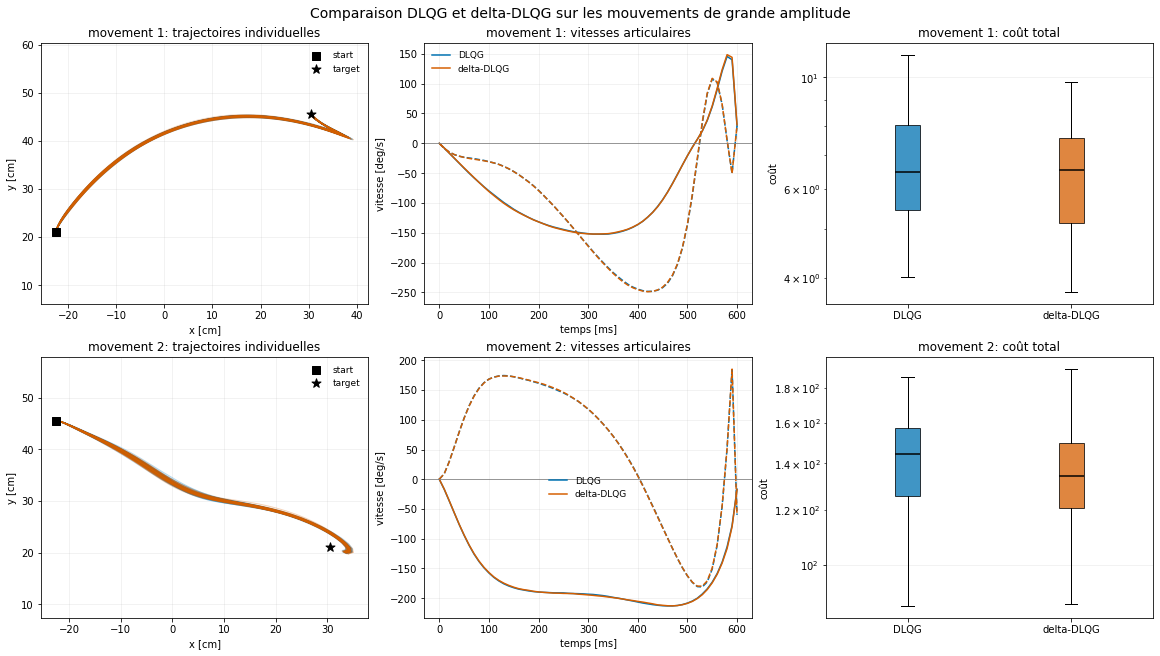

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)
colors = ('#0072B2', '#D55E00')

for row, (name, (movement, data)) in enumerate(results.items()):
    start, target = movement
    trajectory_axis, velocity_axis, cost_axis = axes[row]

    for controller, (label, color) in enumerate(zip(CONTROLLERS, colors)):
        for repetition in range(data['trajectory'].shape[0]):
            trajectory_axis.plot(
                data['trajectory'][repetition, controller, 0],
                data['trajectory'][repetition, controller, 1],
                color=color,
                alpha=0.28,
                linewidth=1.0,
            )

        mean_velocity = np.degrees(data['velocity'][:, controller]).mean(axis=0)
        time = np.linspace(0, DURATION * 1000, NUM_ITER + 1)
        velocity_axis.plot(time, mean_velocity[:, 0], color=color, label=label)
        velocity_axis.plot(time, mean_velocity[:, 1], color=color, linestyle='--')

    trajectory_axis.scatter(start[0], start[1], color='black', marker='s', s=55, label='start', zorder=3)
    trajectory_axis.scatter(target[0], target[1], color='black', marker='*', s=90, label='target', zorder=3)
    trajectory_axis.set_title(f'{name}: trajectoires individuelles')
    trajectory_axis.set_xlabel('x [cm]')
    trajectory_axis.set_ylabel('y [cm]')
    trajectory_axis.set_aspect('equal', adjustable='datalim')
    trajectory_axis.grid(alpha=0.2)
    trajectory_axis.legend(frameon=False, fontsize=9)

    velocity_axis.axhline(0, color='0.5', linewidth=0.8)
    velocity_axis.set_title(f'{name}: vitesses articulaires')
    velocity_axis.set_xlabel('temps [ms]')
    velocity_axis.set_ylabel('vitesse [deg/s]')
    velocity_axis.grid(alpha=0.2)
    velocity_axis.legend(frameon=False, fontsize=9)

    box = cost_axis.boxplot(
        data['cost'],
        tick_labels=CONTROLLERS,
        patch_artist=True,
        showfliers=False,
        medianprops={'color': 'black', 'linewidth': 1.5},
    )
    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    cost_axis.set_title(f'{name}: coût total')
    cost_axis.set_ylabel('coût')
    cost_axis.set_yscale('log')
    cost_axis.grid(axis='y', alpha=0.2)

fig.suptitle('Comparaison DLQG et delta-DLQG sur les mouvements de grande amplitude', fontsize=14)
plt.show()


## Lecture des resultats

Le tableau et les figures comparent le cout total, la trajectoire, les vitesses articulaires et l'erreur terminale. Pour une comparaison finale, augmenter `NUM_SIM` et conserver `noise=True` pour les deux controleurs.